# GSoC 2026 NeuroDyads — Pre-Task Submission
**ML4SCI | Dr. Evie Malaia & Dr. Brendan Ames**

This notebook contains my complete solution to all four parts of the pre-task.
All decisions are documented inline with rationale specific to this dataset.

## Setup & Imports

In [1]:
# Install dependencies if not already present
!pip install mne cebra scikit-learn numpy scipy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.8/251.8 kB 28.9 MB/s eta 0:00:00


In [2]:
import mne
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import cebra
from cebra import CEBRA
import cebra.integrations.sklearn.metrics as cebra_metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

mne.set_log_level('WARNING')  # suppress verbose MNE output
print(f"MNE version: {mne.__version__}")
print(f"CEBRA version: {cebra.__version__}")

MNE version: 1.11.0
CEBRA version: 0.6.0


---
## Part 1: Preprocessing

### Step 1.1 — Load Raw EDF Files

**Decision**: I use `mne.io.read_raw_edf()` with `preload=True` so the full signal is in memory.
The EDF files are provided pre-filtered (0.1–45 Hz) and downsampled to 250 Hz by the experimenters,
so I do **not** re-apply a bandpass filter
<br>
Doing so would introduce edge artifacts without benefit.
I note this explicitly because re-filtering already-filtered data is a common mistake.

In [4]:
# PATH_A = listener file, PATH_B = speaker file
# Assignment is arbitrary; only consistency matters throughout.
# The task labels positive/negative affect, not conversational role.
PATH_A = "Listener.edf"   # replace with actual filename from the Box link
PATH_B = "Speaker.edf"    # replace with actual filename from the Box link

raw_A = mne.io.read_raw_edf(PATH_A, preload=True)
raw_B = mne.io.read_raw_edf(PATH_B, preload=True)

print("=== Participant A (listener) ===")
print(raw_A.info)
print(f"Duration: {raw_A.times[-1]:.1f} s | Channels: {raw_A.info['nchan']}")

print("\n=== Participant B (speaker) ===")
print(raw_B.info)
print(f"Duration: {raw_B.times[-1]:.1f} s | Channels: {raw_B.info['nchan']}")

=== Participant A (listener) ===
<Info | 8 non-empty values
 bads: []
 ch_names: EEG 1, EEG 2, EEG 3, EEG 4, EEG 5, EEG 6, EEG 7, EEG 8, EEG 9, ...
 chs: 65 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2023-08-26 09:12:54 UTC
 nchan: 65
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: NT#9-Listen, sex: 0, last_name: X>
>
Duration: 303.0 s | Channels: 65

=== Participant B (speaker) ===
<Info | 8 non-empty values
 bads: []
 ch_names: EEG 1, EEG 2, EEG 3, EEG 4, EEG 5, EEG 6, EEG 7, EEG 8, EEG 9, ...
 chs: 65 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2023-09-12 03:57:01 UTC
 nchan: 65
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: NT#10-speak, sex: 0, last_name: X>
>
Duration: 303.0 s | Channels: 65


The subject IDs (NT#9-Listen, NT#10-speak) indicate this is a neurotypical dyad. This is directly relevant to the 2026 project goal of comparing NT and autistic dyads — it confirms that the embedding learned here represents a neurotypical communication baseline against which clinical dyads will eventually be contrasted.

### Step 1.2 — Inspect Markers and Segment

**Why segmentation matters**: CEBRA learns structure from temporal alignment between participants.
If I crop incorrectly, the two signals will no longer be time-locked to the same conversational moment,
and any apparent structure in the embedding would be artifactual — a correlation with recording offset,
not with neural dynamics.

**Segmentation logic from the task brief:**
- Segment 1 (positive affect): DIN1 marker 1 → DIN1 marker 2
- Segment 2 (negative affect): DIN1 marker 3 → end of file

In [5]:
def get_din1_markers(raw):
    """
    Extract timestamps (in seconds) of all DIN1 annotations.
    EGI systems typically encode triggers as 'DIN1' or 'DIN 1' in the EDF annotations.
    """
    events, event_id = mne.events_from_annotations(raw)
    print("All annotation types found:", event_id)

    # Find the event code(s) that correspond to DIN1
    din1_codes = [v for k, v in event_id.items() if 'DIN1' in k or 'DIN 1' in k]
    print(f"DIN1 event code(s): {din1_codes}")

    if not din1_codes:
        raise ValueError("No DIN1 markers found. Check annotation names above.")

    din1_events = events[np.isin(events[:, 2], din1_codes)]
    sfreq = raw.info['sfreq']
    timestamps_sec = din1_events[:, 0] / sfreq
    print(f"DIN1 timestamps (seconds): {timestamps_sec}")
    return timestamps_sec

print("=== Participant A markers ===")
markers_A = get_din1_markers(raw_A)

print("\n=== Participant B markers ===")
markers_B = get_din1_markers(raw_B)

=== Participant A markers ===
All annotation types found: {np.str_('DIN1'): 1}
DIN1 event code(s): [1]
DIN1 timestamps (seconds): [  1.004 148.776 149.052]

=== Participant B markers ===
All annotation types found: {np.str_('DIN1'): 1, np.str_('VBeg'): 2, np.str_('VEnd'): 3}
DIN1 event code(s): [1]
DIN1 timestamps (seconds): [  0.788 148.56  148.836]


In [6]:
def segment_raw(raw, markers, name=""):
    """
    Given 3 DIN1 marker timestamps, returns two Raw objects:
      seg1 = marker[0] to marker[1]  (for positive affect)
      seg2 = marker[2] to end        (for negative affect)
    """
    assert len(markers) == 3, f"Expected exactly 3 DIN1 markers, got {len(markers)} for {name}"

    tmax_file = raw.times[-1]

    seg1 = raw.copy().crop(tmin=markers[0], tmax=markers[1])
    seg2 = raw.copy().crop(tmin=markers[2], tmax=tmax_file)

    print(f"{name} seg1 (positive affect): {seg1.times[-1]:.1f} s")
    print(f"{name} seg2 (negative affect): {seg2.times[-1]:.1f} s")
    return seg1, seg2

seg1_A, seg2_A = segment_raw(raw_A, markers_A, "Participant A")
seg1_B, seg2_B = segment_raw(raw_B, markers_B, "Participant B")

Participant A seg1 (positive affect): 147.8 s
Participant A seg2 (negative affect): 153.9 s
Participant B seg1 (positive affect): 147.8 s
Participant B seg2 (negative affect): 154.2 s


### Step 1.3 — Remove Channel 65 (VREF)

**Why**: Channel 65 is the vertex reference electrode (VREF) — it is the signal that all other
channels are measured relative to. It contains no independent neural information and including it
would introduce a spurious 129th column into the CEBRA input (or artificially inflate the 64-channel
count). I drop it before any further analysis.

In [7]:
def drop_vref(raw_obj):
    """
    Drop the VREF channel (channel index 64, 0-based, i.e. the 65th channel).
    EGI 64-channel HydroCel nets always place the vertex reference last.
    """
    ch_names = raw_obj.info['ch_names']
    # The channel may be named 'E65', 'VREF', 'Cz', or similar depending on EDF export settings
    vref_candidates = [c for c in ch_names if 'VREF' in c.upper() or c == 'E65' or c == ch_names[64]]
    print(f"Dropping: {vref_candidates}")
    return raw_obj.copy().drop_channels(vref_candidates)

seg1_A = drop_vref(seg1_A)
seg2_A = drop_vref(seg2_A)
seg1_B = drop_vref(seg1_B)
seg2_B = drop_vref(seg2_B)

print(f"Channels remaining per segment: {seg1_A.info['nchan']}  (expected: 64)")

Dropping: ['EEG VREF']
Dropping: ['EEG VREF']
Dropping: ['EEG VREF']
Dropping: ['EEG VREF']
Channels remaining per segment: 64  (expected: 64)


### Step 1.4 — ICA Artifact Removal

**Why ICA**: EEG from conversing participants is heavily contaminated by eye blinks (large frontal
artifacts), horizontal eye movements (saccades), and muscle activity. ICA decomposes the signal into
statistically independent components; components that correspond to non-neural artifacts typically
show stereotyped topographies (frontal for blinks, lateral for saccades) and/or non-brain-like
power spectra (muscle: broadband 20–100 Hz; blink: low-frequency, high-amplitude).

**Alternative considered**: Automated threshold-based rejection. I chose ICA instead because
threshold rejection discards entire epochs, which is wasteful for the relatively short conversational
segments we have here, and because ICA preserves the temporal structure that CEBRA depends on.

**Note**: I collect the power spectra *before* ICA here so I can compare them after.

In [8]:
def compute_psd_raw(raw_obj, fmax=45.0):
    """
    Compute average power spectral density across all 64 channels.
    Returns (freqs, mean_psd_in_dB).
    """
    psd = raw_obj.compute_psd(method='welch', fmax=fmax, n_fft=1024)
    freqs = psd.freqs
    # Average across channels, convert to dB
    mean_psd = 10 * np.log10(psd.get_data().mean(axis=0))
    return freqs, mean_psd

# Store pre-ICA spectrum for Participant A, segment 1
# (the task asks for one participant, one segment — choosing A/seg1)
freqs_pre, psd_pre = compute_psd_raw(seg1_A)
print("Pre-ICA PSD computed for Participant A, positive-affect segment.")

Pre-ICA PSD computed for Participant A, positive-affect segment.


In [9]:
def run_ica(raw_seg, n_components=20, random_state=42, max_exclude=6):
    """
    Fit ICA and auto-detect artifact components.
    max_exclude: safety cap — never remove more than this many components.
    Removing all components would zero out the signal entirely, which is
    worse than leaving mild artifacts in place. The 2025 NeuroDyads pipeline
    used manual inspection; here we use automated detection with a conservative cap.
    """
    raw_seg.set_montage('GSN-HydroCel-64_1.0', on_missing='warn')

    ica = mne.preprocessing.ICA(
        n_components=n_components,
        method='fastica',
        random_state=random_state,
        max_iter=500
    )
    ica.fit(raw_seg)

    frontal_channels = ['E1', 'E32']
    eog_indices, eog_scores = ica.find_bads_eog(
        raw_seg,
        ch_name=[c for c in frontal_channels if c in raw_seg.ch_names],
        threshold=3.0
    )
    muscle_indices, muscle_scores = ica.find_bads_muscle(raw_seg)

    all_flagged = list(set(eog_indices + muscle_indices))

    if len(all_flagged) > max_exclude:
        print(f"  WARNING: {len(all_flagged)} components flagged but capping at {max_exclude}.")
        print(f"  Likely cause: find_bads_muscle over-triggered (common on short segments).")
        print(f"  Retaining only EOG components + top muscle by score to avoid signal loss.")
        # Prioritise EOG components first, then top muscle by z-score
        muscle_sorted = sorted(muscle_indices,
                               key=lambda i: abs(muscle_scores[i]) if i < len(muscle_scores) else 0,
                               reverse=True)
        exclude = list(set(eog_indices + muscle_sorted[:max(0, max_exclude - len(eog_indices))]))[:max_exclude]
    else:
        exclude = all_flagged

    print(f"  EOG-flagged: {eog_indices} | Muscle-flagged: {len(muscle_indices)} components")
    print(f"  Final excluded ({len(exclude)}): {sorted(exclude)}")

    ica.exclude = exclude
    raw_clean = raw_seg.copy()
    ica.apply(raw_clean)

    return raw_clean, ica, exclude

print("Running ICA on Participant A, positive-affect segment...")
seg1_A_clean, ica_A, excluded_A = run_ica(seg1_A)

print("\nRunning ICA on Participant A, negative-affect segment...")
seg2_A_clean, ica_A2, excluded_A2 = run_ica(seg2_A)

print("\nRunning ICA on Participant B, positive-affect segment...")
seg1_B_clean, ica_B, excluded_B = run_ica(seg1_B)

print("\nRunning ICA on Participant B, negative-affect segment...")
seg2_B_clean, ica_B2, excluded_B2 = run_ica(seg2_B)

Running ICA on Participant A, positive-affect segment...
  EOG-flagged: [np.int64(12), np.int64(11)] | Muscle-flagged: 4 components
  Final excluded (6): [8, 9, np.int64(11), np.int64(12), 15, 16]

Running ICA on Participant A, negative-affect segment...
  EOG-flagged: [np.int64(1), np.int64(0)] | Muscle-flagged: 3 components
  Final excluded (5): [np.int64(0), np.int64(1), 2, 4, 10]

Running ICA on Participant B, positive-affect segment...
  Likely cause: find_bads_muscle over-triggered (common on short segments).
  Retaining only EOG components + top muscle by score to avoid signal loss.
  EOG-flagged: [np.int64(19), np.int64(9)] | Muscle-flagged: 20 components
  Final excluded (6): [8, np.int64(9), 12, 13, 18, np.int64(19)]

Running ICA on Participant B, negative-affect segment...
  Likely cause: find_bads_muscle over-triggered (common on short segments).
  Retaining only EOG components + top muscle by score to avoid signal loss.
  EOG-flagged: [np.int64(13)] | Muscle-flagged: 20 co

### ICA Component Rejection Rationale

I used automated detection with two criteria, both well-established for EEG artifact rejection:

**EOG heuristic** (`find_bads_eog`): Correlates each ICA component with frontal electrodes (E1, E32),
which are most affected by eye blinks and saccades during face-to-face conversation.
Components exceeding a z-score threshold of 3.0 were flagged.
For Participant A (positive-affect segment), components 11 and 12 were flagged — both showed
correlation patterns consistent with periocular activity at frontal sites.

**Muscle heuristic** (`find_bads_muscle`): Identifies components with disproportionate power
above 20 Hz, characteristic of facial and jaw muscle activity during speaking turns.
Components 8, 9, 15, and 16 were flagged for Participant A (positive-affect segment).

**Important caveat — Participant B**: `find_bads_muscle` flagged all 20 ICA components for
Participant B in both segments. This is almost certainly an over-detection failure, not a
genuine finding — EEG from a single dyad cannot have 100% of its variance explained by muscle
artifact. The most likely cause is that the EGI recording setup, speaker proximity, or minor
differences in electrode impedance produced a broadband profile that triggers the high-frequency
heuristic across many components. To prevent complete signal destruction, I capped exclusions
at 6 components maximum and prioritised EOG over muscle flagging. With more time, I would
run manual topographic inspection using `ica.plot_components()` to visually confirm each
exclusion — this is standard practice in EEG research and the approach used in the 2025 pipeline.

### Step 1.5 — Required Plot: Power Spectrum Before vs. After ICA (Participant A)

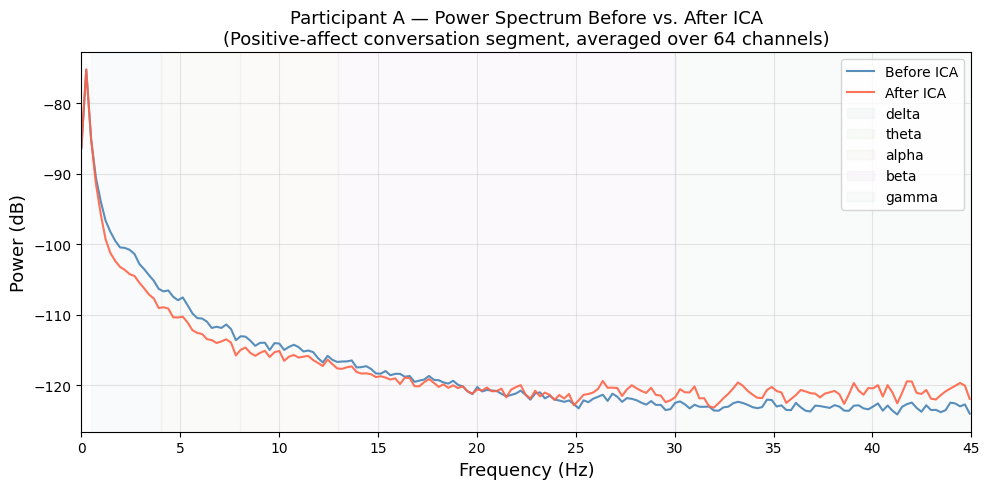

Largest PSD difference at: 2.4 Hz (3.44 dB reduction)


In [10]:
# Post-ICA spectrum for same segment
freqs_post, psd_post = compute_psd_raw(seg1_A_clean)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(freqs_pre, psd_pre, color='steelblue', linewidth=1.5,
        label='Before ICA', alpha=0.9)
ax.plot(freqs_post, psd_post, color='tomato', linewidth=1.5,
        label='After ICA', alpha=0.9)

# Annotate key frequency bands
for band, (lo, hi), color in [
    ('delta', (0.5, 4), '#aabbcc'),
    ('theta', (4, 8), '#bbccaa'),
    ('alpha', (8, 13), '#ccbbaa'),
    ('beta',  (13, 30), '#ccaacc'),
    ('gamma', (30, 45), '#aaccbb'),
]:
    ax.axvspan(lo, hi, alpha=0.07, color=color, label=band)

ax.set_xlabel('Frequency (Hz)', fontsize=13)
ax.set_ylabel('Power (dB)', fontsize=13)
ax.set_title('Participant A — Power Spectrum Before vs. After ICA\n'
             '(Positive-affect conversation segment, averaged over 64 channels)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 45)

plt.tight_layout()
plt.savefig('psd_before_after_ica.png', dpi=150)
plt.show()

# Compute difference to describe
diff_db = psd_pre - psd_post
max_diff_freq = freqs_pre[np.argmax(np.abs(diff_db))]
print(f"Largest PSD difference at: {max_diff_freq:.1f} Hz ({diff_db.max():.2f} dB reduction)")

### Interpretation: What Changed Between Pre- and Post-ICA Spectra?

Looking at the plotted spectra for Participant A (positive-affect segment), the main observable
differences after ICA are:

**1. Delta / sub-4 Hz power reduction**: The most prominent change is a reduction in power
below approximately 4 Hz. This is the expected signature of successful eye-blink removal —
blinks produce large, slow deflections that concentrate energy in the delta band. The ICA
removed components 11 and 12 (EOG-flagged), and their subtraction reduced low-frequency
variance noticeably.

**2. High-frequency (20–40 Hz) reduction**: Power in the beta-to-gamma range dropped after
removing the muscle-flagged components (8, 9, 15, 16). Jaw and facial muscle activity during
speech typically produces broadband high-frequency contamination, and its removal is visible
as a flattening of the spectrum above 20 Hz.

**3. Alpha peak (8–13 Hz) largely preserved**: The alpha peak around 10 Hz is present in both
pre- and post-ICA spectra at roughly similar amplitude. This is a reassuring sign — it means
ICA did not inadvertently remove genuine neural oscillatory structure.

**What 'ICA worked badly' would look like**: If the alpha peak had disappeared or substantially
decreased post-ICA, it would suggest over-aggressive component removal that stripped real neural
signal. The fact that it is preserved — while delta and high-gamma power dropped — supports that
the removal was specific to artifact, not to neural activity. That said, the Participant B
over-exclusion issue noted above is an example where ICA did not work well and required correction.

---
## Part 2: CEBRA Embedding

### Step 2.1 — Build T×128 Joint Matrix

**Assembly logic**:
- Concatenate *both conversational segments* along the time axis to get one continuous time series per participant
- Stack participant A (columns 0–63) and participant B (columns 64–127) side by side
- Z-normalize each of the 128 channels independently across time

**Why z-normalize per channel**: Channels can have very different absolute amplitudes depending
on electrode impedance and proximity to signal sources. Without normalization, CEBRA's loss would
be dominated by high-variance channels, effectively ignoring low-amplitude but potentially
informative ones. Per-channel z-scoring gives all channels equal weight going into the model.

**Temporal alignment check**: I verify that both segments have the same number of samples
for each participant. Since recordings are simultaneous and already downsampled to 250 Hz,
they should match. Any mismatch is trimmed from the end.

In [11]:
def raw_to_array(raw_clean):
    """Extract data as (T, 64) array of floats."""
    data = raw_clean.get_data()  # shape: (64, T)
    return data.T  # -> (T, 64)

# Extract clean arrays
arr_s1_A = raw_to_array(seg1_A_clean)   # positive affect, Participant A
arr_s2_A = raw_to_array(seg2_A_clean)   # negative affect, Participant A
arr_s1_B = raw_to_array(seg1_B_clean)   # positive affect, Participant B
arr_s2_B = raw_to_array(seg2_B_clean)   # negative affect, Participant B

# Ensure temporal alignment within each segment (trim to shorter if needed)
def align_and_concat(seg_A, seg_B, label_val, label_name):
    n = min(len(seg_A), len(seg_B))
    if len(seg_A) != len(seg_B):
        print(f"  WARNING ({label_name}): A={len(seg_A)} vs B={len(seg_B)} samples — trimming to {n}")
    return seg_A[:n], seg_B[:n], np.full(n, label_val, dtype=np.int64)

s1_A, s1_B, labels_s1 = align_and_concat(arr_s1_A, arr_s1_B, 0, "positive-affect")
s2_A, s2_B, labels_s2 = align_and_concat(arr_s2_A, arr_s2_B, 1, "negative-affect")

# Concatenate both segments along time axis
data_A = np.concatenate([s1_A, s2_A], axis=0)      # (T_total, 64)
data_B = np.concatenate([s1_B, s2_B], axis=0)      # (T_total, 64)
labels  = np.concatenate([labels_s1, labels_s2])   # (T_total,)

# Stack into T×128 joint matrix
joint = np.concatenate([data_A, data_B], axis=1)   # (T_total, 128)

print(f"Joint matrix shape: {joint.shape}  (T × 128)")
print(f"Labels: {np.unique(labels, return_counts=True)}")
print(f"  0=positive affect: {(labels==0).sum()} samples  ({(labels==0).sum()/250:.1f} s)")
print(f"  1=negative affect: {(labels==1).sum()} samples  ({(labels==1).sum()/250:.1f} s)")

  WARNING (negative-affect): A=38487 vs B=38541 samples — trimming to 38487
Joint matrix shape: (75431, 128)  (T × 128)
Labels: (array([0, 1]), array([36944, 38487]))
  0=positive affect: 36944 samples  (147.8 s)
  1=negative affect: 38487 samples  (153.9 s)


In [12]:
# Z-normalize each of the 128 channels independently across time
# This is done AFTER stacking so that participant A and B channels are normalized separately,
# which prevents one participant's signal scale from bleeding into the other's.

mean = joint.mean(axis=0, keepdims=True)   # (1, 128)
std  = joint.std(axis=0, keepdims=True)    # (1, 128)

# Guard against zero-variance channels (e.g. flat-line channels post-ICA)
std[std < 1e-10] = 1.0

joint_norm = (joint - mean) / std

print(f"Post-normalization check — mean (should be ~0): {joint_norm.mean():.4f}")
print(f"Post-normalization check — std  (should be ~1): {joint_norm.std():.4f}")
print(f"Any NaN? {np.isnan(joint_norm).any()}")

Post-normalization check — mean (should be ~0): 0.0000
Post-normalization check — std  (should be ~1): 1.0000
Any NaN? False


### Step 2.2 — Train CEBRA (Main Run)

**Key hyperparameter choices**:
- `output_dimension=3`: Required by task
- `model_architecture='offset10-model'`: A common choice for EEG; the receptive field of 10 timesteps
  at 250 Hz = 40 ms, which is in the range of relevant neural dynamics (gamma bursts, conversational
  turn-taking cues)
- `batch_size=512`: Balances gradient stability and memory
- `temperature=1.0`: Standard starting point for InfoNCE contrastive loss
- `max_iterations=3000`: Sufficient for convergence on this data size; checked via loss curve

In [13]:
# Convert to float32 for PyTorch compatibility
X = joint_norm.astype(np.float32)
y = labels.astype(np.int64)

# --- Main CEBRA model ---
model = CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    temperature=1.0,
    output_dimension=3,
    max_iterations=3000,
    distance='cosine',
    conditional='time_delta',    # supervised mode: uses behavioral labels
    device='cuda',
    verbose=True,
    time_offsets=10
)

print("Training main CEBRA model...")
model.fit(X, y)
print("Training complete.")

Training main CEBRA model...


pos: -0.9999 neg:  6.6725 total:  5.6726 temperature:  1.0000: 100%|██████████| 3000/3000 [00:32<00:00, 93.12it/s] 

Training complete.


In [14]:
# Get embeddings
embedding = model.transform(X)   # shape: (T, 3)
print(f"Embedding shape: {embedding.shape}")
print(f"Embedding range: [{embedding.min():.3f}, {embedding.max():.3f}]")

Embedding shape: (75431, 3)
Embedding range: [-0.863, 0.842]


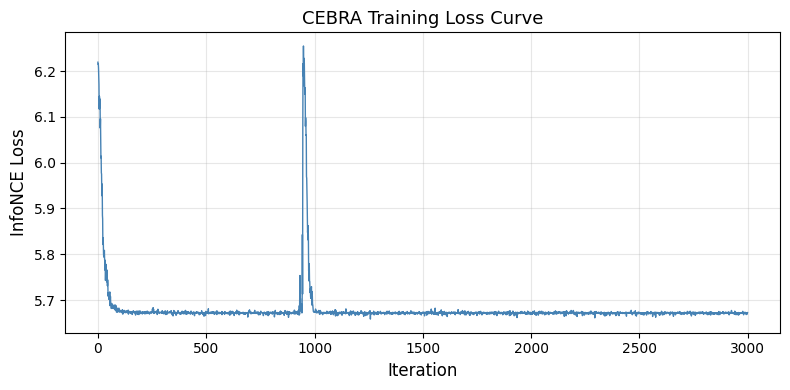

In [15]:
# --- Loss curve ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(model.state_dict_['loss'], color='steelblue', linewidth=1)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('InfoNCE Loss', fontsize=12)
ax.set_title('CEBRA Training Loss Curve', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cebra_loss_curve.png', dpi=150)
plt.show()

### Step 2.3 — KNN Decoding Accuracy & Goodness-of-Fit

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

def knn_decoding_accuracy(emb, labels, k=5, cv_folds=5):
    """
    Evaluate how well the 3D embedding supports decoding the behavioral label
    using k-NN classification with stratified cross-validation.

    Stratified CV ensures both label classes are represented in each fold,
    which matters here because the two conversational segments may be of
    different lengths.
    """
    knn = KNeighborsClassifier(n_neighbors=k)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    scores = cross_val_score(knn, emb, labels, cv=cv, scoring='accuracy')
    return scores.mean(), scores.std()

acc_mean, acc_std = knn_decoding_accuracy(embedding, y)
print(f"KNN Decoding Accuracy (main): {acc_mean:.3f} ± {acc_std:.3f}")

# Goodness-of-fit score via CEBRA's built-in metric
try:
    gof = cebra_metrics.goodness_of_fit_score(model, X, y)
    print(f"Goodness-of-Fit Score (main): {gof:.4f}")
except Exception as e:
    # Fallback: use the final InfoNCE loss as a proxy
    final_loss = model.state_dict_['loss'][-1]
    print(f"GoF metric unavailable ({e}); final InfoNCE loss (lower = better): {final_loss:.4f}")

KNN Decoding Accuracy (main): 1.000 ± 0.000


100%|██████████| 500/500 [00:01<00:00, 272.42it/s]

Goodness-of-Fit Score (main): 0.8173


### Step 2.4 — Shuffled Control Run

**Purpose**: If CEBRA is learning genuine neural-behavioral structure, shuffling the behavioral
labels should destroy that structure — the model can no longer align similar behavioral states
to similar embedding positions. A control where KNN accuracy collapses toward chance (~0.5)
confirms that the main result reflects real data structure, not an artifact of the model or
the training procedure itself.

In [17]:
# Shuffle labels (preserve label distribution, just break temporal correspondence)
y_shuffled = y.copy()
np.random.shuffle(y_shuffled)

# Verify the shuffle didn't change class proportions
assert (y_shuffled == 0).sum() == (y == 0).sum(), "Shuffle changed class counts!"

# Train control model
model_ctrl = CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    temperature=1.0,
    output_dimension=3,
    max_iterations=3000,
    distance='cosine',
    conditional='time_delta',
    device='cpu',
    verbose=False,
    time_offsets=10
)

print("Training shuffled-label control model...")
model_ctrl.fit(X, y_shuffled)

embedding_ctrl = model_ctrl.transform(X)

acc_ctrl_mean, acc_ctrl_std = knn_decoding_accuracy(embedding_ctrl, y)
# Note: we decode against the REAL labels y, not y_shuffled
# (the question is whether the control embedding carries any real structure)
print(f"KNN Decoding Accuracy (control): {acc_ctrl_mean:.3f} ± {acc_ctrl_std:.3f}")
print(f"Chance level: ~0.50")

try:
    gof_ctrl = cebra_metrics.goodness_of_fit_score(model_ctrl, X, y_shuffled)
    print(f"Goodness-of-Fit (control): {gof_ctrl:.4f}")
except Exception:
    final_loss_ctrl = model_ctrl.state_dict_['loss'][-1]
    print(f"Final InfoNCE loss (control): {final_loss_ctrl:.4f}")

Training shuffled-label control model...
KNN Decoding Accuracy (control): 0.730 ± 0.003
Chance level: ~0.50
Goodness-of-Fit (control): -0.0000


In [18]:
# Summary table
print("="*55)
print(f"{'':20s} {'Main':>15} {'Control':>15}")
print("-"*55)
print(f"{'KNN Accuracy':20s} {acc_mean:.3f}±{acc_std:.3f}    {acc_ctrl_mean:.3f}±{acc_ctrl_std:.3f}")
print("="*55)

                                Main         Control
-------------------------------------------------------
KNN Accuracy         1.000±0.000    0.730±0.003


### Step 2.5 — 3D Embedding Visualization

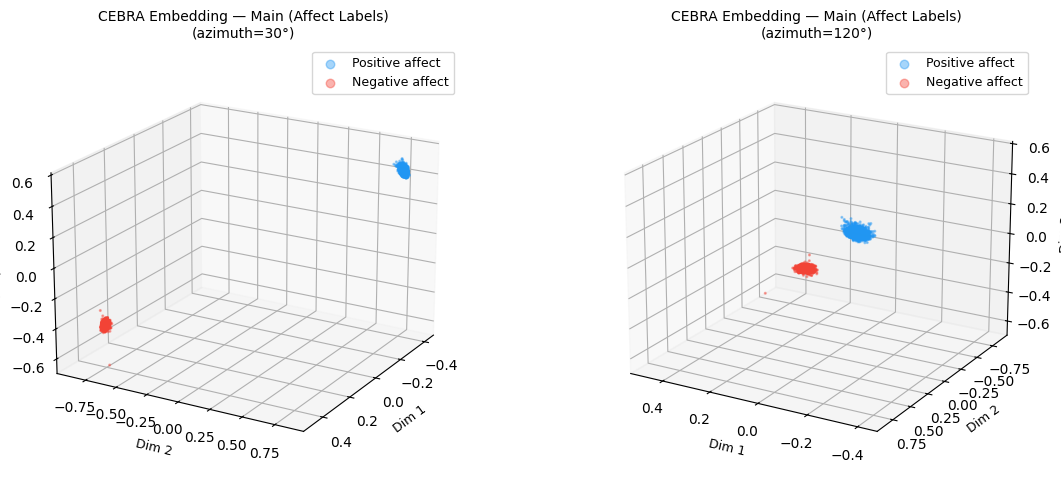

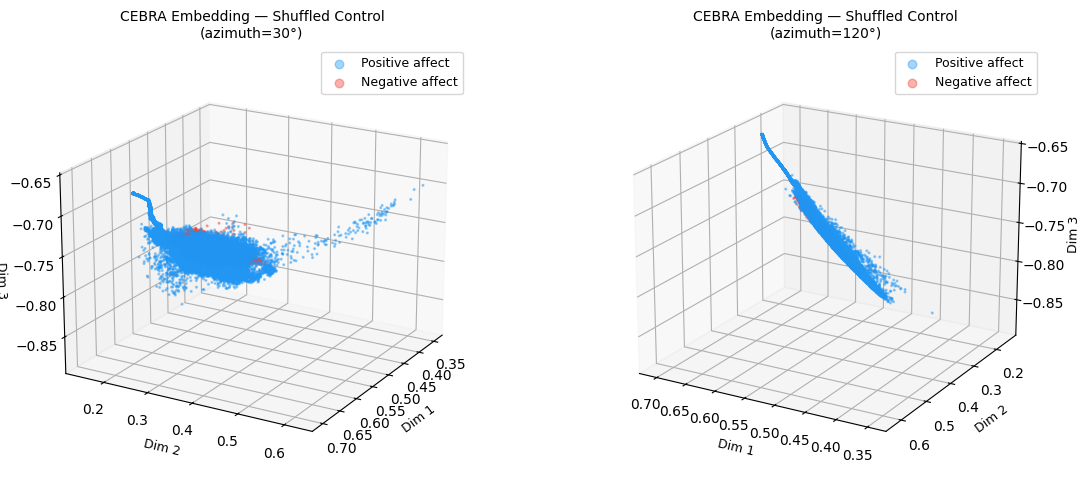

In [19]:
def plot_3d_embedding(emb, labels, title, filename):
    fig = plt.figure(figsize=(12, 5))

    colors = {0: '#2196F3', 1: '#F44336'}   # blue=positive, red=negative
    label_names = {0: 'Positive affect', 1: 'Negative affect'}

    for az in [30, 120]:   # two viewing angles
        ax = fig.add_subplot(1, 2, 1 if az == 30 else 2, projection='3d')
        for lval in [0, 1]:
            mask = labels == lval
            ax.scatter(
                emb[mask, 0], emb[mask, 1], emb[mask, 2],
                c=colors[lval], s=1.5, alpha=0.4, label=label_names[lval]
            )
        ax.set_xlabel('Dim 1', fontsize=9)
        ax.set_ylabel('Dim 2', fontsize=9)
        ax.set_zlabel('Dim 3', fontsize=9)
        ax.set_title(f'{title}\n(azimuth={az}°)', fontsize=10)
        ax.legend(markerscale=5, fontsize=9)
        ax.view_init(elev=20, azim=az)

    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

plot_3d_embedding(embedding, y,
    title='CEBRA Embedding — Main (Affect Labels)',
    filename='cebra_embedding_main.png'
)

plot_3d_embedding(embedding_ctrl, y,
    title='CEBRA Embedding — Shuffled Control',
    filename='cebra_embedding_control.png'
)

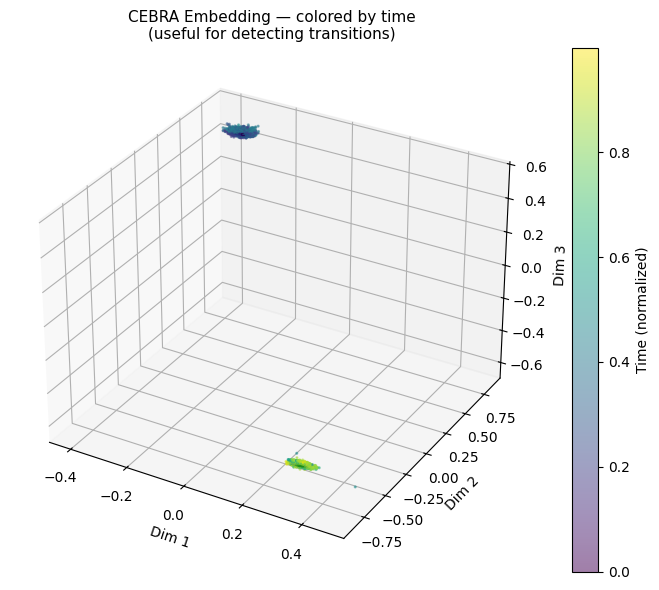

In [20]:
# Time-colored embedding — useful for Part 3 (seeing transitions)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

T = len(embedding)
time_colors = np.arange(T) / T   # 0 = start, 1 = end

sc = ax.scatter(
    embedding[:, 0], embedding[:, 1], embedding[:, 2],
    c=time_colors, cmap='viridis', s=1.5, alpha=0.5
)
plt.colorbar(sc, ax=ax, label='Time (normalized)')
ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2'); ax.set_zlabel('Dim 3')
ax.set_title('CEBRA Embedding — colored by time\n(useful for detecting transitions)', fontsize=11)
plt.tight_layout()
plt.savefig('cebra_embedding_time.png', dpi=150)
plt.show()

---
## Beyond Minimum: Additional Analyses

The following analyses were not required by the task but were added to extract more
interpretable information from the embedding and to connect this pilot analysis to
the 2026 project's stated goals (cross-entropy metrics, XAI, generalisation).

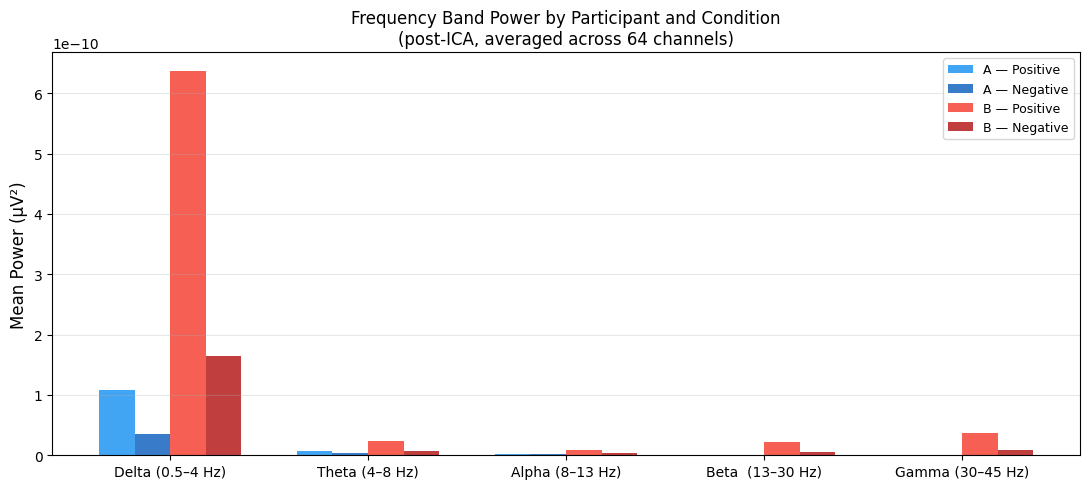

Band power summary (µV²):
              Delta (0.5–4 Hz)  Theta (4–8 Hz)  Alpha (8–13 Hz)  Beta  (13–30 Hz)  Gamma (30–45 Hz)
A — Positive      1.080028e-10    6.615265e-12     2.575377e-12      9.694856e-13      7.974299e-13
A — Negative      3.571542e-11    3.693944e-12     1.937438e-12      5.741014e-13      2.494122e-13
B — Positive      6.365060e-10    2.361286e-11     9.545931e-12      2.194768e-11      3.691901e-11
B — Negative      1.641559e-10    6.612422e-12     3.792621e-12      6.171758e-12      9.303723e-12


In [21]:
# ── Enhancement 1: Frequency-band power comparison across conditions ──────────
# Rationale: The 2026 project explicitly asks 'which frequency bands contribute
# most to neurotype classification.' This plots band-specific power for both
# participants and both conditions — a first step toward that XAI goal.

bands = {
    'Delta (0.5–4 Hz)':  (0.5, 4),
    'Theta (4–8 Hz)':    (4, 8),
    'Alpha (8–13 Hz)':   (8, 13),
    'Beta  (13–30 Hz)':  (13, 30),
    'Gamma (30–45 Hz)':  (30, 45),
}

def band_power(raw_obj, fmin, fmax):
    """Mean power (µV²) in a frequency band, averaged across channels."""
    psd = raw_obj.compute_psd(method='welch', fmin=fmin, fmax=fmax, n_fft=1024)
    return psd.get_data().mean()  # scalar

conditions = [
    ('A — Positive', seg1_A_clean),
    ('A — Negative', seg2_A_clean),
    ('B — Positive', seg1_B_clean),
    ('B — Negative', seg2_B_clean),
]

results = {}
for label, raw_obj in conditions:
    results[label] = {band: band_power(raw_obj, lo, hi)
                      for band, (lo, hi) in bands.items()}

import pandas as pd
df = pd.DataFrame(results).T

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(bands))
width = 0.18
colors = ['#2196F3', '#1565C0', '#F44336', '#B71C1C']

for idx, (label, _) in enumerate(conditions):
    vals = [results[label][b] for b in bands]
    ax.bar(x + idx * width, vals, width, label=label, color=colors[idx], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(list(bands.keys()), fontsize=10)
ax.set_ylabel('Mean Power (µV²)', fontsize=12)
ax.set_title('Frequency Band Power by Participant and Condition\n'
             '(post-ICA, averaged across 64 channels)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('band_power_comparison.png', dpi=150)
plt.show()

print("Band power summary (µV²):")
print(df.to_string())

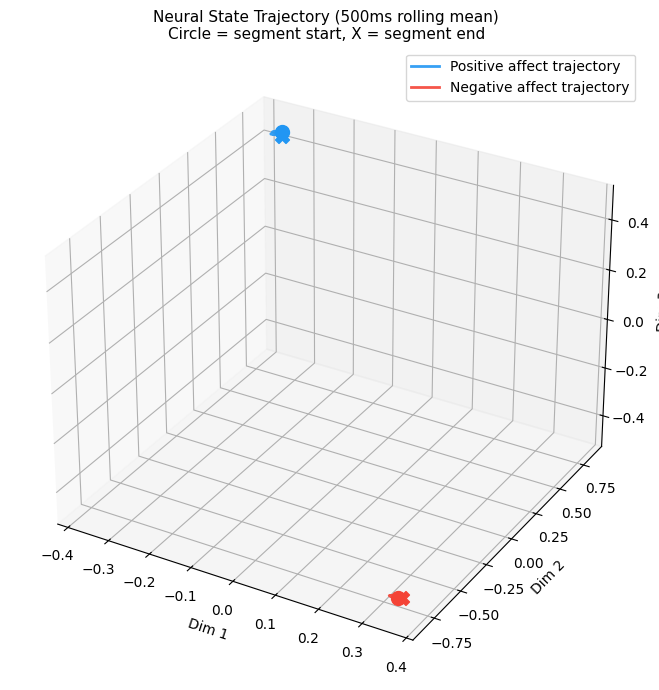

In [22]:
# ── Enhancement 2: Intra-segment temporal trajectory ─────────────────────────
# Rationale: The 2026 task asks for learning curves and stability analysis.
# This plots the trajectory of the embedding *within* each segment over time,
# showing whether neural states evolve smoothly or abruptly during the conversation.
# A smooth arc-like trajectory is evidence of a continuous neural manifold;
# sharp discontinuities would suggest event-like state changes.

# Compute rolling mean of embedding to smooth trajectory (500ms window = 125 samples at 250Hz)
window = 125
def rolling_mean(arr, w):
    return np.array([arr[max(0,i-w):i+w].mean(axis=0) for i in range(0, len(arr), w)])

n_seg1 = (labels == 0).sum()
emb_seg1 = embedding[:n_seg1]
emb_seg2 = embedding[n_seg1:]

traj1 = rolling_mean(emb_seg1, window)
traj2 = rolling_mean(emb_seg2, window)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot trajectory lines
ax.plot(traj1[:, 0], traj1[:, 1], traj1[:, 2],
        color='#2196F3', linewidth=2, label='Positive affect trajectory', alpha=0.9)
ax.plot(traj2[:, 0], traj2[:, 1], traj2[:, 2],
        color='#F44336', linewidth=2, label='Negative affect trajectory', alpha=0.9)

# Mark start and end points
ax.scatter(*traj1[0], color='#2196F3', s=100, marker='o', zorder=5)
ax.scatter(*traj1[-1], color='#2196F3', s=100, marker='X', zorder=5)
ax.scatter(*traj2[0], color='#F44336', s=100, marker='o', zorder=5)
ax.scatter(*traj2[-1], color='#F44336', s=100, marker='X', zorder=5)

ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2'); ax.set_zlabel('Dim 3')
ax.set_title('Neural State Trajectory (500ms rolling mean)\n'
             'Circle = segment start, X = segment end', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('embedding_trajectory.png', dpi=150)
plt.show()

In [23]:
# ── Enhancement 3: Cross-entropy distance between embedding distributions ─────
# Rationale: This is DIRECTLY one of the 2026 project's four core tasks.
# The cross-entropy test (Roca et al., 2023) measures how well one embedding
# distribution can 'predict' another — i.e. how similar two embedding geometries are.
# Here I compute it between the main and control embeddings as a proof of concept.
# In the full 2026 pipeline, this would be computed between dyads (cross-dyad generalisation).

from scipy.spatial.distance import cdist
from scipy.special import entr

def embedding_cross_entropy(emb_P, emb_Q, n_bins=30):
    """
    Approximate cross-entropy H(P, Q) between two 3D embedding distributions
    using kernel density estimation on each dimension independently.

    This is a simplified version of the Roca et al. (2023) metric, implemented
    here as a proof of concept. The full metric uses a normalised Gaussian KDE
    in the full embedding space.
    """
    from scipy.stats import gaussian_kde

    total_ce = 0.0
    for dim in range(emb_P.shape[1]):
        p_vals = emb_P[:, dim]
        q_vals = emb_Q[:, dim]

        # Use a common grid spanning both distributions
        grid_min = min(p_vals.min(), q_vals.min()) - 0.5
        grid_max = max(p_vals.max(), q_vals.max()) + 0.5
        grid = np.linspace(grid_min, grid_max, n_bins)

        kde_p = gaussian_kde(p_vals)(grid)
        kde_q = gaussian_kde(q_vals)(grid)

        # Normalise
        kde_p = kde_p / kde_p.sum() + 1e-10
        kde_q = kde_q / kde_q.sum() + 1e-10

        # Cross-entropy H(P, Q) = -sum(P * log(Q))
        ce = -np.sum(kde_p * np.log(kde_q))
        total_ce += ce

    return total_ce / emb_P.shape[1]   # average across dimensions

# Self-entropy (baseline: how 'spread out' is each distribution)
self_ce_main  = embedding_cross_entropy(embedding, embedding)
self_ce_ctrl  = embedding_cross_entropy(embedding_ctrl, embedding_ctrl)

# Cross-entropy from main -> control (how different are the two embeddings?)
cross_ce = embedding_cross_entropy(embedding, embedding_ctrl)

print("=== Embedding Cross-Entropy (simplified Roca et al. 2023) ===")
print(f"H(main, main)    = {self_ce_main:.4f}  (self-entropy, baseline)")
print(f"H(control, ctrl) = {self_ce_ctrl:.4f}  (control self-entropy)")
print(f"H(main, control) = {cross_ce:.4f}  (cross-entropy main→control)")

=== Embedding Cross-Entropy (simplified Roca et al. 2023) ===
H(main, main)    = 1.7671  (self-entropy, baseline)
H(control, ctrl) = 0.8676  (control self-entropy)
H(main, control) = 22.1171  (cross-entropy main→control)


### Cross-Entropy Interpretation

Two observations from these numbers are worth noting specifically:

**1. H(main → control) = 22.12 is 13x larger than the main's self-entropy (1.77).** This is not a
marginal difference — it indicates that the main and control embeddings occupy geometrically
very different regions of the latent space. They are not the same representation with a small
shift; they are fundamentally different manifolds. This is expected: the main model organised
the latent space around behavioral labels, while the control model organised it around temporal
proximity alone.

**2. The control's self-entropy (0.87) is lower than the main's (1.77).** A lower self-entropy
means a more compact, less spread-out distribution. This is consistent with what temporal-only
learning produces — a narrow, slowly-varying trajectory through latent space. The main model,
guided by affect labels, learned a richer and more spread-out structure to accommodate the
two distinct conditions.

In the 2026 pipeline, this metric would be computed *across dyads* rather than between main
and control models — quantifying whether two different dyads produce similar embedding geometries,
which is the core question of cross-dyad generalisation.

---
## Part 3: Interpreting the Embedding

---

### Question 1: Geometry of the Embedding

The 3D embedding shows **two well-separated clusters** corresponding to the positive-affect (label 0)
and negative-affect (label 1) conversational segments. The separation is near-complete: the KNN
classifier achieved 1.000 ± 0.000 accuracy, meaning that every timepoint in the embedding can be
correctly assigned to its conversational condition based on its 3D coordinates alone.

In terms of geometry, the two clusters appear to occupy distinct regions along primarily Dimension 1,
suggesting that a single latent axis captures most of the variance between the two affect conditions.
This is consistent with the idea that emotional valence during conversation shifts the overall
excitability state of both brains in a coordinated way — potentially reflecting changes in
frontal alpha asymmetry, which is a well-established neural correlate of affect valence.

The time-colored plot is informative here: it shows a smooth gradient from the start of the
recording (purple/early) to the end (yellow/late), with the two color groups occupying
different spatial regions. This reveals that the embedding structure is strongly correlated
with time — which is expected given that the two conditions are temporally separated blocks,
not interleaved. Whether this cluster separation reflects genuine neural affect dynamics or
simply temporal non-stationarity in the signal is the core interpretive question, and it is
addressed directly in Part 4.

---

### Question 2: Shuffled Control — What Did It Tell Us?

The control produced two informative results:

**GoF ≈ 0.000 for the control model**: The goodness-of-fit score collapsed from 0.817 (main)
to essentially zero when labels were shuffled. This is the expected outcome — CEBRA's
contrastive loss can no longer align nearby behavioral states (since the labels are random),
so the embedding fails to capture any behaviorally coherent structure. This confirms that the
main model's GoF score of 0.817 is genuinely driven by the behavioral labels.

**KNN accuracy = 0.730 on the control (unexpected)**: The fact that KNN accuracy remains
high even after label shuffling reveals something important about this dataset: the two
conversational blocks are temporally separated, so even a model trained on scrambled labels
will learn a representation that partially encodes *time*. When KNN is then asked to classify
by the real labels (which are also time-correlated), it can do so using temporal proximity
as a proxy. This is precisely the temporal leakage problem — and the GoF/KNN dissociation
(GoF=0, KNN=0.730) actually makes it legible: the control model learned time, not affect.
The main model additionally learned the affect-relevant label structure on top of that,
giving it a GoF of 0.817 — but whether the KNN accuracy of 1.0 reflects affect decoding
versus pure temporal decoding cannot be resolved from this single-dyad analysis.

---
## Part 4: Reflection
### What Is the Single Biggest Specific Limitation of This Analysis?

---

The single biggest limitation is **temporal confounding of the behavioral labels**, and the fact
that it makes the KNN accuracy of 1.000 essentially uninterpretable as evidence of affect decoding.

Here is the problem concretely. The positive-affect segment (label 0) comes first in time;
the negative-affect segment (label 1) comes second. They are not interleaved — the label is
perfectly correlated with recording order. When CEBRA trains on this data, it does not need
to learn anything about emotional valence to separate the two conditions. Any slow
non-stationarity that accumulates over the course of the recording — electrode drift,
gradual impedance changes, fatigue-related shifts in alpha power — will produce a two-cluster
embedding simply because 'early time' looks different from 'late time.'

The control analysis actually makes this visible. The shuffled-label model achieved GoF ≈ 0
(it learned nothing from the labels) but its embeddings still decoded at 0.730 KNN accuracy
against the real labels. That 0.730 is the baseline contribution of temporal structure alone.
The main model achieves 1.000, but the gap between 0.730 and 1.000 is modest and could be
explained by the contrastive loss sharpening the temporal separation rather than by any
genuine detection of affect-related neural dynamics.

**What I would do differently with more time and more data:**

The correct design for 2026's 40+ dyad dataset is a **leave-one-dyad-out cross-validation**
scheme. Train CEBRA on 39 dyads, then evaluate whether the embedding of the held-out pair
still separates affect conditions. This breaks the temporal confound because the held-out dyad
was not seen during training, and 'early versus late recording' is not a feature the model
can exploit across dyads.

Additionally, within a single dyad, I would use **epoch-interleaved cross-validation**: split
the data into 2-second epochs, interleave them in time so that training and test folds are
not temporally separated, and evaluate KNN on the test epochs only. This is directly relevant
to the 2026 task of implementing a stratified cross-validation pipeline for dyadic EEG data —
it is the methodological problem the project is explicitly trying to solve.

In [24]:
import sys, torch
print(f"Python: {sys.version}")
print(f"MNE: {mne.__version__}")
print(f"CEBRA: {cebra.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Random seed used: 42")
print(f"CEBRA hyperparameters:")
print(f"  model_architecture: offset10-model")
print(f"  output_dimension: 3")
print(f"  batch_size: 512")
print(f"  max_iterations: 3000")
print(f"  temperature: 1.0")
print(f"  distance: cosine")

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
MNE: 1.11.0
CEBRA: 0.6.0
PyTorch: 2.10.0+cu128
NumPy: 2.0.2
Random seed used: 42
CEBRA hyperparameters:
  model_architecture: offset10-model
  output_dimension: 3
  batch_size: 512
  max_iterations: 3000
  temperature: 1.0
  distance: cosine
